In [81]:
# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Regression
import patsy
import statsmodels.api as sm

# Parameterization
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [82]:
# Loads dataset 
df = pd.read_csv('previsao_de_renda.csv', index_col=0)
print("✅Dataset loaded successfully!")

# Drop columns
df = df.drop(columns=['index','mau'])
df.head()

✅Dataset loaded successfully!


,data_ref,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,2015-01-01,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,3369.24
1,2015-01-01,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,6096.14
2,2015-01-01,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,5658.98
3,2015-01-01,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,7246.69
4,2015-01-01,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,4017.37


In [ ]:
# Dataset structure
print("="*50)
print("Dataset structure🔎".center(50))
print("="*50)

df.info()

                Dataset structure🔎                
<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data_ref               15000 non-null  object 
 1   sexo                   15000 non-null  object 
 2   posse_de_veiculo       15000 non-null  bool   
 3   posse_de_imovel        15000 non-null  bool   
 4   qtd_filhos             15000 non-null  int64  
 5   tipo_renda             15000 non-null  object 
 6   educacao               15000 non-null  object 
 7   estado_civil           15000 non-null  object 
 8   tipo_residencia        15000 non-null  object 
 9   idade                  15000 non-null  int64  
 10  tempo_emprego          12466 non-null  float64
 11  qt_pessoas_residencia  15000 non-null  float64
 12  renda                  15000 non-null  float64
dtypes: bool(2), float64(3), int64(2), object(6)
memory usage: 1.

In [84]:
# Design matrix
y, X = patsy.dmatrices(
    'renda ~ tempo_emprego',
    data=df,
    return_type='dataframe'
)

# Regression model
linear_model = sm.OLS(y,X).fit()

# Summary of the regression model
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  renda   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     2294.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:33:40   Log-Likelihood:            -1.2249e+05
No. Observations:               12466   AIC:                         2.450e+05
Df Residuals:                   12464   BIC:                         2.450e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2653.9453     60.924     43.561      0.000    2534.525    2773.366
tempo_emprego   283.3509      5.916     47.892      0.000     271.754     294.948
==============================================================================
Omnibus:                     9974.393   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           387626.996
Skew:                           3.561   Prob(JB):                         0.00
Kurtosis:                      29.373   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

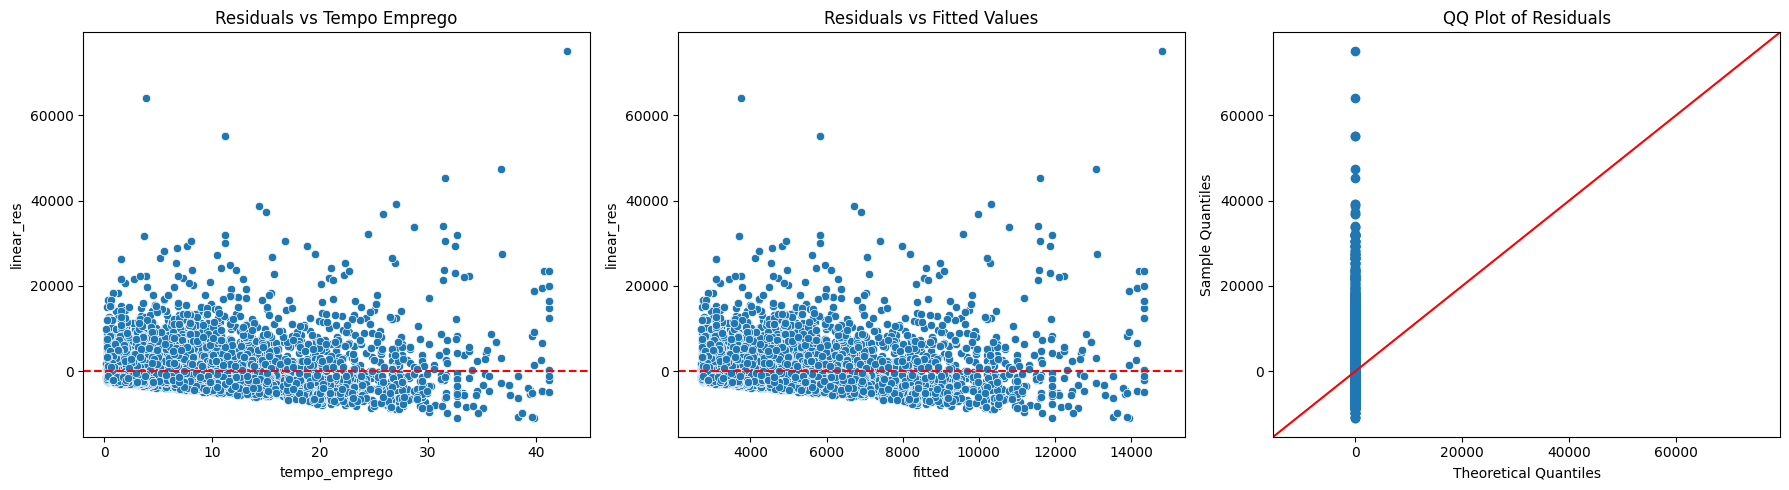

                                                                                                                 Insight🔎                                                                                                                 
It will be necessary to apply a log transformation to the income variable to reduce skewness and improve the model fit,and include additional explanatory variables for a better specification.


In [ ]:
# Residuals columns
df.loc[X.index, 'linear_res'] = linear_model.resid
df.loc[X.index, 'fitted'] = linear_model.fittedvalues

# grid 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Residuals vs tempo_emprego
sns.scatterplot(
    x='tempo_emprego',
    y='linear_res',
    data=df,
    ax=axes[0]
)
axes[0].axhline(0, color= 'r', linestyle='--')
axes[0].set_title('Residuals vs Tempo Emprego')

# 2) Residuals vs fitted
sns.scatterplot(
    x='fitted',
    y='linear_res',
    data=df,
    ax=axes[1]
)
axes[1].axhline(0, color= 'r', linestyle='--')
axes[1].set_title('Residuals vs Fitted Values')

# 3) QQ-plot
sm.qqplot(linear_model.resid, line='45', ax=axes[2])
axes[2].set_title('QQ Plot of Residuals')

plt.tight_layout()
plt.show()


print("="*234)
print("Insight🔎".center(234))
print("="*234)
print("""It will be necessary to apply a log transformation to the income variable to reduce skewness and improve the model fit,and include additional explanatory variables for a better specification.""")

In [120]:
# Design matrix
y, X = patsy.dmatrices(
    'np.log(renda) ~ tempo_emprego + sexo + posse_de_imovel + idade',
    data=df,
    return_type='dataframe'
)

# Regression model
log_model = sm.OLS(y,X).fit()

# Summary of the regression model
log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          np.log(renda)   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     907.7
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:52:03   Log-Likelihood:                -13335.
No. Observations:               12466   AIC:                         2.668e+04
Df Residuals:                   12461   BIC:                         2.672e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   7.3732      0.030    243.856      0.000       7.314       7.432
sexo[T.M]                   0.4742      0.013     35.424      0.000       0.448       0.500
posse_de_imovel[T.True]     0.1018      0.013      7.649      0.000       0.076       0.128
tempo_emprego               0.0479      0.001     48.283      0.000       0.046       0.050
idade                       0.0043      0.001      5.958      0.000       0.003       0.006
==============================================================================
Omnibus:                        1.296   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.523   Jarque-Bera (JB):                1.272
Skew:                           0.011   Prob(JB):                        0.529
Kurtosis:                       3.045   Cond. No.                         207.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

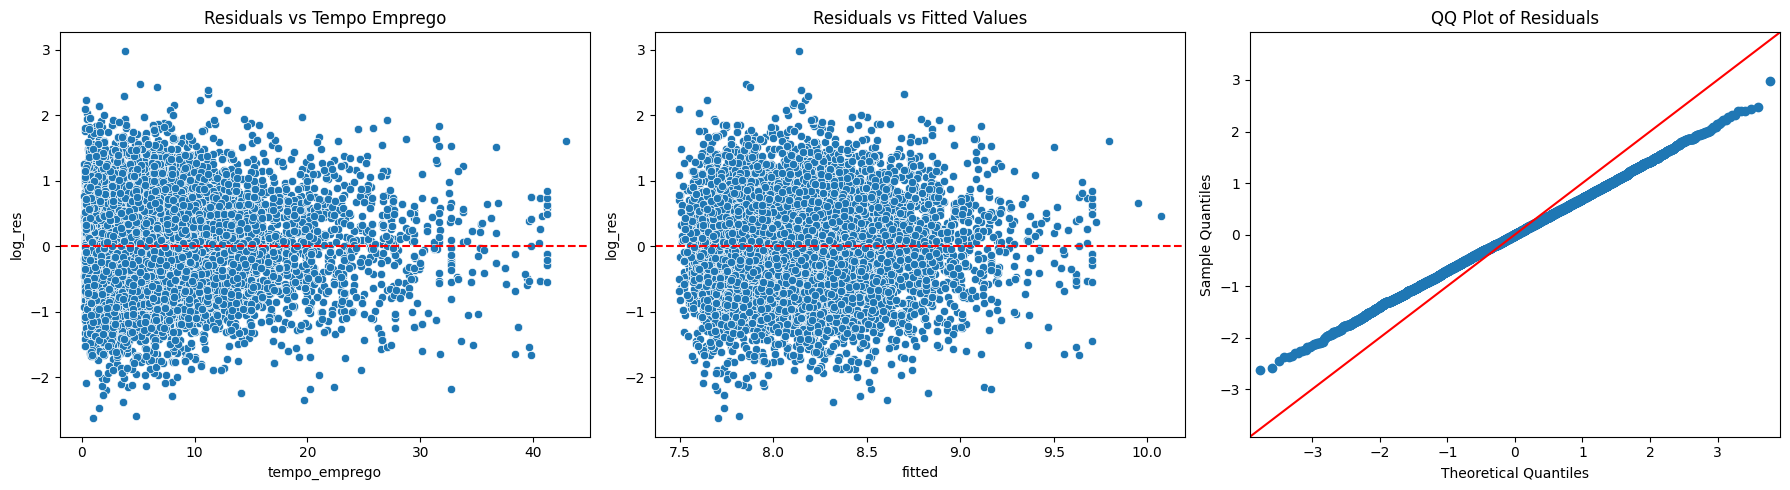

                                                                                                               Conclusion🧠                                                                                                                
The model achieved a statistically consistent specification after applying the log transformation to income and adding relevant explanatory variables. The residual diagnostics indicate normality and independence,
satisfying the main OLS assumptions. All predictors are statistically significant and economically interpretable, providing a reliable explanation of income variation,
even with a moderate R-squared, which is expected for individual-level income data.


In [147]:
# Residuals columns
df.loc[X.index, 'log_res'] = log_model.resid
df.loc[X.index, 'fitted'] = log_model.fittedvalues

# grid 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Residuals vs tempo_emprego
sns.scatterplot(
    x='tempo_emprego',
    y='log_res',
    data=df,
    ax=axes[0]
)
axes[0].axhline(0, color= 'r', linestyle='--')
axes[0].set_title('Residuals vs Tempo Emprego')

# 2) Residuals vs fitted
sns.scatterplot(
    x='fitted',
    y='log_res',
    data=df,
    ax=axes[1]
)
axes[1].axhline(0, color= 'r', linestyle='--')
axes[1].set_title('Residuals vs Fitted Values')

# 3) QQ-plot
sm.qqplot(log_model.resid, line='45', ax=axes[2])
axes[2].set_title('QQ Plot of Residuals')

plt.tight_layout()
plt.show()


print("="*234)
print("Conclusion🧠".center(234))
print("="*234)
print("""The model achieved a statistically consistent specification after applying the log transformation to income and adding relevant explanatory variables. The residual diagnostics indicate normality and independence,
satisfying the main OLS assumptions. All predictors are statistically significant and economically interpretable, providing a reliable explanation of income variation,
even with a moderate R-squared, which is expected for individual-level income data.""")
